In [15]:
# ============================================================
# PLANT DISEASE DETECTION USING CNN
# ============================================================
# Import TensorFlow for building and training the deep learning model.
import tensorflow as tf

# Import Sequential to create the CNN model layer by layer.
from tensorflow.keras.models import Sequential

# Import convolution and pooling layers used to extract image features.
from tensorflow.keras.layers import Conv2D, MaxPooling2D

# Import Flatten, Dense, and Dropout layers for classification.
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Import ImageDataGenerator to load and preprocess images from folders.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Import matplotlib to draw accuracy and loss graphs.
import matplotlib.pyplot as plt

In [16]:
# Set the path where the plant disease image dataset is stored.
# The dataset folder should contain one subfolder for each plant disease class.
dataset_path = r"E:\LP5\my pen1\DL\4.DL plant\PlantVillage\small"

# Create an ImageDataGenerator for preprocessing images.
# rescale=1./255 converts pixel values from 0-255 to 0-1.
# validation_split=0.2 keeps 20% of images for validation/testing.
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load training images from the dataset folder.
# target_size resizes all images to 128x128 pixels.
# class_mode='categorical' is used because there are multiple disease classes.
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Load validation images from the same folder using the validation split.
# These images are used to check model performance during training.
test_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 210 images belonging to 4 classes.
Found 52 images belonging to 4 classes.


In [17]:
# Build a Convolutional Neural Network (CNN) model for image classification.
model = Sequential()

# Add the first convolution layer with 32 filters.
# It looks for simple image patterns such as edges and colors.
# input_shape=(128,128,3) means each image is 128x128 with 3 color channels.
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

# Add max pooling to reduce image size while keeping important features.
model.add(MaxPooling2D((2,2)))

# Add the second convolution layer with 64 filters.
# This layer learns more detailed patterns from the image.
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Reduce the feature map size again using max pooling.
model.add(MaxPooling2D((2,2)))

# Add the third convolution layer with 128 filters.
# This layer can learn higher-level disease patterns from leaves.
model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))

# Apply max pooling after the third convolution layer.
model.add(MaxPooling2D((2,2)))

In [18]:
# Flatten the 2D feature maps into a 1D vector.
# Dense layers need the data in this flattened format.
model.add(Flatten())

# Add a fully connected Dense layer to learn classification patterns.
model.add(Dense(256, activation='relu'))

# Dropout turns off 50% of neurons during training to reduce overfitting.
model.add(Dropout(0.5))

# Add the output layer.
# The number of neurons equals the number of plant disease classes.
# Softmax gives the probability for each class.
model.add(Dense(
    train_data.num_classes,
    activation='softmax'
))

# Compile the model before training.
# Adam updates weights, categorical_crossentropy handles multi-class classification,
# and accuracy tracks how many predictions are correct.
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print a summary of all model layers and trainable parameters.
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,517,060 (24.86 MB)

 Trainable params: 6,517,060 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train the CNN model using the training images.
# validation_data checks the model on validation images after each epoch.
# epochs=10 means the model sees the full training dataset 10 times.
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

# Save the trained model to an H5 file so it can be reused later.
model.save("plant_disease_model.h5")

# Print a message after the model is saved successfully.
print("Model Saved Successfully!")

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 338ms/step - accuracy: 0.2857 - loss: 1.8554 - val_accuracy: 0.2692 - val_loss: 1.3824
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - accuracy: 0.3000 - loss: 1.3852 - val_accuracy: 0.4615 - val_loss: 1.3675
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 235ms/step - accuracy: 0.3238 - loss: 1.3874 - val_accuracy: 0.3846 - val_loss: 1.3434
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - accuracy: 0.4190 - loss: 1.3260 - val_accuracy: 0.5385 - val_loss: 1.2776
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 280ms/step - accuracy: 0.4619 - loss: 1.2377 - val_accuracy: 0.4808 - val_loss: 1.1367
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step - accuracy: 0.6190 - loss: 1.0049 - val_accuracy: 0.6923 - val_loss: 0.9137
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 260ms/step - accuracy: 0.6524 - loss: 0.9086 - val_accuracy: 0.5000 - val_loss: 1.0843
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step - accuracy: 0.6238 - loss: 0.9412 - val_accuracy: 0.5192 - val_loss:

Model Saved Successfully!


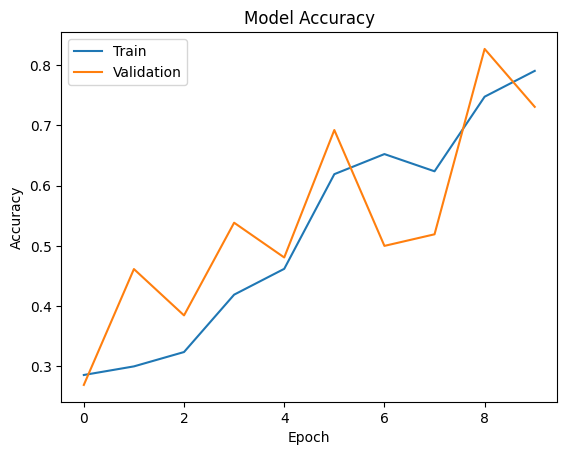

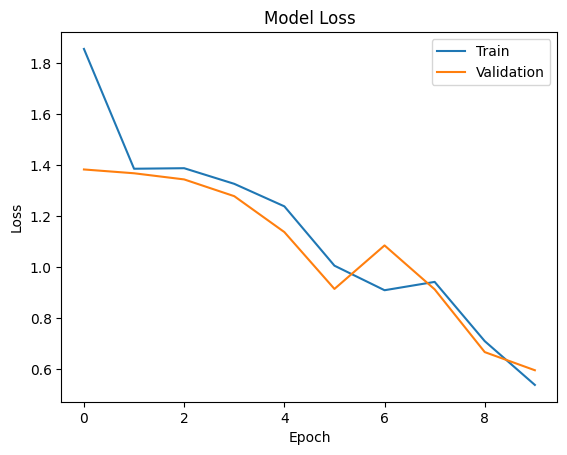

In [20]:
# Plot training accuracy and validation accuracy across epochs.
# This shows how well the model learns over time.
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

# Plot training loss and validation loss across epochs.
# Lower loss means the model is making fewer errors.
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
# This cell is intentionally left blank.

In [ ]:
# This cell is intentionally left blank.

In [ ]:
# This cell is intentionally left blank.

In [ ]:
# This cell is intentionally left blank.